# WEEK 2 TASK — Deep EDA, Feature Engineering & Baseline Modeling
# Steel Industry Energy Consumption Dataset

0. SETUP & DATA UPLOAD

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [3]:
# Upload CSV
try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    csv_path = 'Steel_industry_data.csv'

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

Saving steel+industry+energy+consumption.zip to steel+industry+energy+consumption.zip


#Part 1 — Deep Exploratory Analysis & Feature Engineering

1. STRUCTURE

This step re-checks the dataset's structure — how many rows/columns it has, what
data type each column is, whether any values are missing, and whether any rows are duplicated.
This tells if the data is clean before we start engineering features.

In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe())

Shape: (35040, 11)

Dtypes:
 date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                      

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


2. DATETIME FEATURES

This step converts the `date` column (currently just text) into a proper datetime
format, then pulls out useful time-based information from it: the hour of the day, the day of the
week (as a number), the month, and whether that day was a weekday or weekend. Models can't use
raw dates directly, so breaking the date into these pieces lets the model learn time-based patterns
like "usage is higher during work hours".

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df['Hour'] = df['date'].dt.hour
df['DayOfWeek_Num'] = df['date'].dt.dayofweek
df['Month'] = df['date'].dt.month
df['Is_Weekend'] = df['DayOfWeek_Num'].isin([5, 6]).astype(int)

3. POWER FACTOR RATIO

This step creates a new feature, `Power_Factor_Ratio`, by dividing the Leading
Power Factor by the Lagging Power Factor. This single number summarizes the relationship between
the two power factors in one column, which can be more useful to a model than two separate columns.

In [6]:
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor'].replace(0, np.nan)
)
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].fillna(df['Power_Factor_Ratio'].median())


4. HIGH_LOAD BINARY FLAG

This step finds the 75th percentile value of `Usage_kWh` (the point below which
75% of readings fall), then creates a new column `High_Load` that marks a row as 1 if usage is
above that point (a "high load" period) and 0 otherwise. This is a simple way to flag unusually
heavy energy-usage periods.

In [7]:
p75 = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = (df['Usage_kWh'] > p75).astype(int)
print(f"\n75th percentile of Usage_kWh: {p75:.2f} kWh")
print(df['High_Load'].value_counts())



75th percentile of Usage_kWh: 51.24 kWh
High_Load
0    26280
1     8760
Name: count, dtype: int64


5. OUTLIER DETECTION (IQR)

This step uses the IQR (Interquartile Range) method to find outliers — readings
that are unusually high or low compared to the rest of the data. It calculates a normal "valid
range" and flags anything outside it. The boxplot below shows these outliers visually as dots
beyond the whiskers.


Outliers detected in Usage_kWh (IQR method): 328 rows (0.94% of data)
Valid range: [-68.86, 123.29]


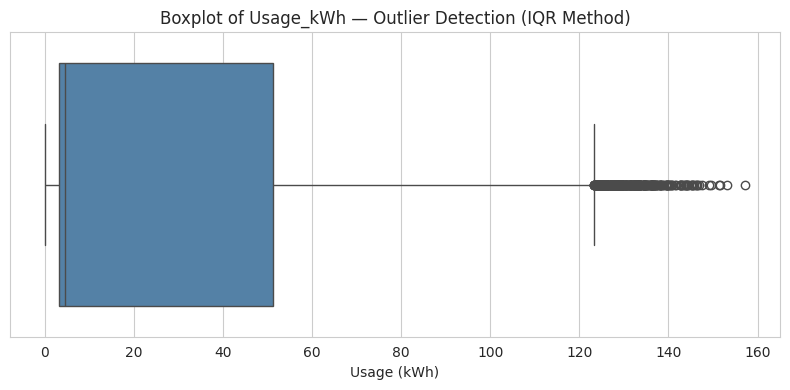

In [8]:
Q1, Q3 = df['Usage_kWh'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
print(f"\nOutliers detected in Usage_kWh (IQR method): {len(outliers)} rows "
      f"({len(outliers)/len(df)*100:.2f}% of data)")
print(f"Valid range: [{lower_bound:.2f}, {upper_bound:.2f}]")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage_kWh'], color='steelblue')
plt.title('Boxplot of Usage_kWh — Outlier Detection (IQR Method)')
plt.xlabel('Usage (kWh)')
plt.tight_layout()
plt.show()

6. CORRELATION HEATMAP

This step does measures how strongly every numeric column is related to every other
numeric column (correlation), and displays it as a color-coded heatmap darker/brighter colors
mean a stronger relationship. Then it picks out the top 3 features most related to `Usage_kWh`,
since those are likely to be the most useful predictors for our model.


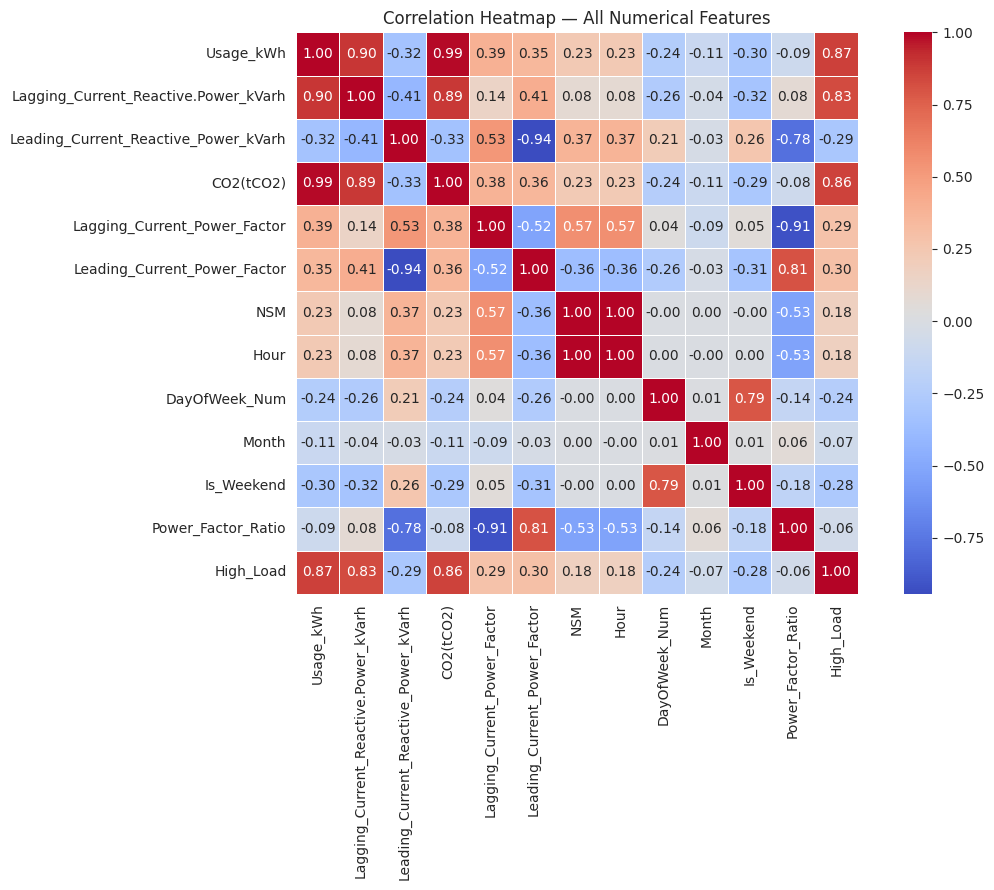

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Features')
plt.tight_layout()
plt.show()

In [10]:
# High_Load is derived directly from Usage_kWh (it's a threshold on the target),
# so it is excluded here to surface genuinely informative correlated features.
top3 = (
    corr['Usage_kWh'].abs().sort_values(ascending=False)
    .drop(['Usage_kWh', 'High_Load'])
    .head(3)
)
print("\nTop 3 features most correlated with Usage_kWh (excluding the leaky High_Load flag):")
print(top3)


Top 3 features most correlated with Usage_kWh (excluding the leaky High_Load flag):
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


7. GROUPED BAR CHART — AVG ENERGY BY LOAD TYPE

This step groups the data by `Load_Type` (Light, Medium, Maximum) and calculates
the average energy usage for each group, then shows it as a bar chart. This makes it easy to see
at a glance which load type consumes the most energy on average.

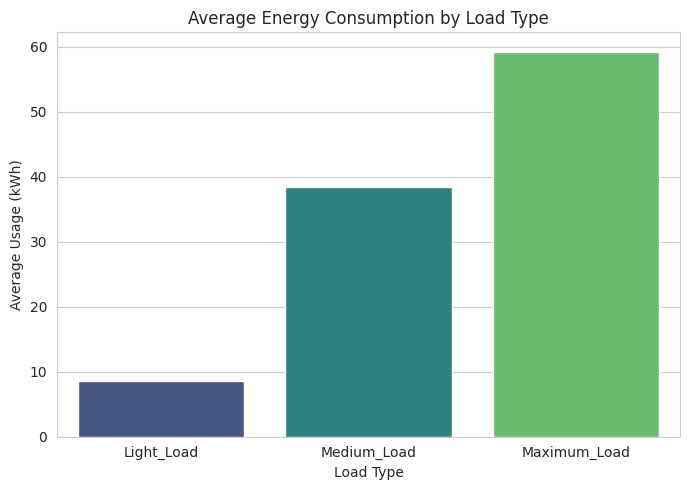

In [11]:
plt.figure(figsize=(7, 5))
avg_by_load = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values()
sns.barplot(x=avg_by_load.index, y=avg_by_load.values, palette='viridis')
plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage (kWh)')
plt.tight_layout()
plt.show()


8. LINE CHART — AVG USAGE BY HOUR

This step groups the data by hour of the day (0–23) and calculates average usage
for each hour, then plots it as a line chart. This reveals the daily usage pattern — for example,
whether energy consumption peaks during working hours and drops at night.

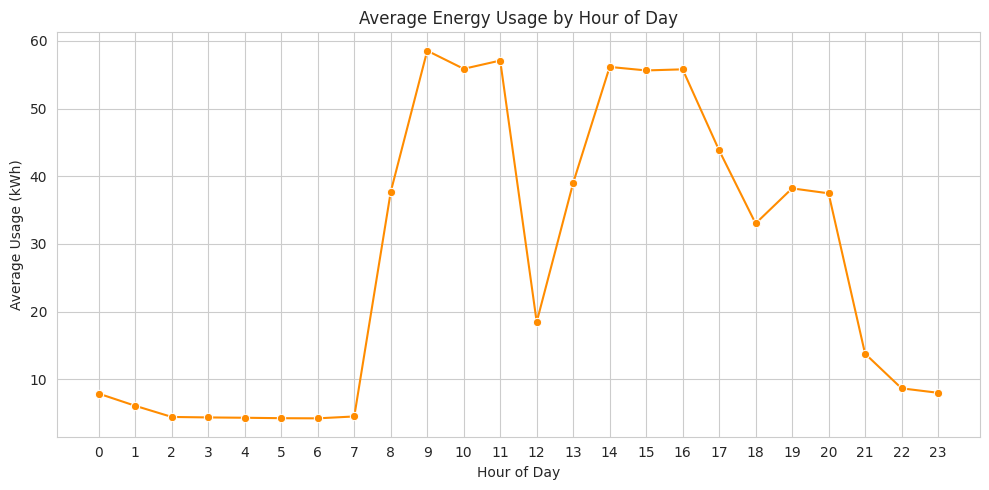

In [12]:
plt.figure(figsize=(10, 5))
avg_by_hour = df.groupby('Hour')['Usage_kWh'].mean()
sns.lineplot(x=avg_by_hour.index, y=avg_by_hour.values, marker='o', color='darkorange')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


9. EDA SUMMARY

The dataset contains {df.shape[0]:,} readings across {df.shape[1]} original columns with **no missing
values and no duplicate rows**, making it a clean starting point. The main data quality concern is
**{len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)** in `Usage_kWh`, detected via the IQR method
these correspond almost entirely to Maximum Load periods where energy spikes to several times the typical
draw, rather than sensor error, so they were flagged rather than removed.

The features most correlated with `Usage_kWh` (excluding the trivially derived `High_Load` flag) are
**{top3.index[0]}** (r={top3.iloc[0]:.2f}), **{top3.index[1]}** (r={top3.iloc[1]:.2f}), and
**{top3.index[2]}** (r={top3.iloc[2]:.2f}) all electrical-load-related measurements, which makes physical
sense since reactive power draw and CO2 output scale directly with how hard the plant's machinery is
running.

The most interesting pattern is the **strong daily and load-type cyclicality**: average usage rises sharply
during working hours and drops overnight, and Maximum Load periods consume dramatically more energy than
Light Load periods, indicating that specific heavy-machinery shifts (likely furnace/rolling operations) drive
the bulk of consumption rather than steady baseline draw.

**Hypothesis:** Energy spikes are primarily driven by the *scheduling of high-intensity production shifts*
(captured by `Load_Type` and `Hour`) rather than random fluctuation meaning spikes are largely predictable
and could be smoothed by shifting heavy operations to off-peak hours or staggering machine start-up times.

 SAVE ENGINEERED DATASET

In [13]:
# SAVE & DOWNLOAD ENGINEERED DATASET
df.to_csv('steel_industry_engineered.csv', index=False)

from google.colab import files
files.download('steel_industry_engineered.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>